# MITR for Logical Reasoning - BERT & RoBERTa Experiments
## ICLR 2026 Workshop on Logical Reasoning of LLMs

### Why BERT and RoBERTa?

Our DistilBERT results showed that **CKA-based MITR** reduces logical contradictions
with minimal accuracy cost. But DistilBERT is a 6-layer model distilled *from* BERT.
Two natural questions arise:

1. **BERT (12 layers)** - Does MITR work on the *teacher* model? With 12 layers
   there are 11 consecutive layer pairs (vs 5 in DistilBERT), so there is more
   potential for redundancy - and more room for MITR to help.

2. **RoBERTa (12 layers)** - RoBERTa uses a fundamentally different pretraining
   recipe: no Next Sentence Prediction, dynamic masking, 10x more data, BPE
   tokenizer. If MITR works here too, it shows the method generalizes across
   training paradigms - not just the BERT family.

| Model | Layers | Hidden | Params | Pretraining | Tokenizer |
|-------|--------|--------|--------|-------------|----------|
| DistilBERT | 6 | 768 | 66M | Distillation from BERT | WordPiece |
| **BERT-base** | **12** | **768** | **110M** | MLM + NSP | WordPiece |
| **RoBERTa-base** | **12** | **768** | **125M** | MLM only (no NSP) | BPE |

### What we expect

- BERT/RoBERTa should have **higher baseline accuracy** than DistilBERT (more capacity)
- With 12 layers, there's more room for **inter-layer redundancy** - MITR should
  have a bigger effect on consistency
- CKA should remain the best strategy (structural similarity is architecture-agnostic)
- If CKA works on RoBERTa (different pretraining), the method is **training-paradigm agnostic**

> Based on prior DistilBERT experiments in `logical_reasoning_mitr_a100.ipynb`

In [1]:
# Run once - installs / upgrades required packages
!pip install -q --upgrade "transformers>=4.36" datasets accelerate matplotlib seaborn tqdm
print("Done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 12.9 MB/s eta 0:00:00
Done.


In [2]:
import os, json, random, warnings
from dataclasses import dataclass, field
from typing import Dict, List, Optional
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    DistilBertModel, DistilBertTokenizerFast,
    BertModel, BertTokenizerFast,
    RobertaModel, RobertaTokenizerFast,
    AutoModel, AutoTokenizer,
    get_cosine_schedule_with_warmup,
)
from datasets import load_dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

PyTorch : 2.10.0+cu128
CUDA    : True


In [3]:
@dataclass
class Config:
    # -- Model --
    model_name: str  = "bert-base-uncased"
    num_labels: int  = 2

    # -- Training --
    batch_size: int       = 32     # BERT/RoBERTa are 2x DistilBERT -> halve batch
    eval_batch_size: int  = 64
    learning_rate: float  = 2e-5
    weight_decay: float   = 0.01
    num_epochs: int       = 3 # for time
    warmup_ratio: float   = 0.06
    max_grad_norm: float  = 1.0
    grad_accum_steps: int = 2      # effective batch = 32 * 2 = 64 (matches DistilBERT)

    # -- MITR --
    mi_lambda: float     = 0.01
    mi_warmup_steps: int = 200
    club_hidden: int     = 384
    mi_strategy: str     = "club"

    # -- Data --
    dataset: str         = "boolq"
    max_length: int      = 256
    num_train: int       = 5000 # for time
    num_eval: int        = 500 # for time
    num_contra: int      = 500
    num_workers: int     = 4

    # -- A100 --
    use_bf16: bool       = True
    compile_model: bool  = True
    seed: int            = 42

    # -- Output --
    output_dir: str      = "experiment_results"


# We'll run experiments for these backbones
BACKBONES = [
    "bert-base-uncased",
    "roberta-base",
]

# Focus on the two best strategies from DistilBERT + baseline
MI_STRATEGIES = ["InfoNCE"]

print("Backbones:", BACKBONES)
print("Strategies:", MI_STRATEGIES)

Backbones: ['bert-base-uncased', 'roberta-base']
Strategies: ['InfoNCE']


In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = (
    torch.bfloat16
    if torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    else torch.float32
)

print(f"Device : {DEVICE}")
print(f"Dtype  : {DTYPE}")
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}")
    print(f"VRAM   : {props.total_memory / 1e9:.1f} GB")

Device : cuda
Dtype  : torch.bfloat16
GPU    : Tesla T4
VRAM   : 15.6 GB


In [5]:
# -- Load BoolQ --

def load_boolq():
    ds = load_dataset("google/boolq")
    def fmt(ex):
        return {
            "text":     ex["question"] + " [SEP] " + ex["passage"][:400],
            "label":    int(ex["answer"]),
            "question": ex["question"],
        }
    train = ds["train"].map(fmt, remove_columns=ds["train"].column_names)
    val   = ds["validation"].map(fmt, remove_columns=ds["validation"].column_names)
    return train, val


rng = random.Random(42)

def subsample(dataset, n):
    if n < 0 or n >= len(dataset):
        return dataset
    return dataset.select(rng.sample(range(len(dataset)), n))


print("Loading BoolQ ...")
train_raw, val_raw = load_boolq()
train_raw = subsample(train_raw, 8000)
val_raw   = subsample(val_raw,   1500)

tl = [x["label"] for x in train_raw]
vl = [x["label"] for x in val_raw]
print(f"Train : {len(train_raw):,}  (True={sum(tl)}, False={len(tl)-sum(tl)})")
print(f"Val   : {len(val_raw):,}  (True={sum(vl)}, False={len(vl)-sum(vl)})")

Loading BoolQ ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.69M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Map:   0%|          | 0/9427 [00:00<?, ? examples/s]

Map:   0%|          | 0/3270 [00:00<?, ? examples/s]

Train : 8,000  (True=5001, False=2999)
Val   : 1,500  (True=956, False=544)


In [6]:
# -- Contradiction pairs (same as DistilBERT experiments) --

_AUX = [
    ("is ",     "is not "),
    ("are ",    "are not "),
    ("was ",    "was not "),
    ("were ",   "were not "),
    ("does ",   "does not "),
    ("do ",     "do not "),
    ("did ",    "did not "),
    ("has ",    "has not "),
    ("have ",   "have not "),
    ("had ",    "had not "),
    ("can ",    "cannot "),
    ("could ",  "could not "),
    ("will ",   "will not "),
    ("would ",  "would not "),
    ("should ", "should not "),
]

def negate_question(q: str) -> Optional[str]:
    q = q.strip().rstrip("?").lower()
    for pos, neg in _AUX:
        if q.startswith(neg):
            return pos + q[len(neg):]
        if q.startswith(pos):
            return neg + q[len(pos):]
    return None


def create_contradiction_pairs(dataset, n_pairs: int) -> List[Dict]:
    pairs: List[Dict] = []
    for ex in dataset:
        q = ex.get("question", "").strip()
        if not q:
            continue
        q_neg = negate_question(q)
        if q_neg is None or q_neg.strip() == q.strip():
            continue
        text_fwd = ex["text"]
        if "[SEP]" in text_fwd:
            prefix   = text_fwd.split("[SEP]")[0]
            text_neg = prefix + "[SEP] " + q_neg
        else:
            text_neg = q_neg
        pairs.append({
            "text_forward":    text_fwd,
            "text_negated":    text_neg,
            "label_forward":   ex["label"],
            "label_negated":   1 - ex["label"],
            "question":        q,
            "negated_question": q_neg,
        })
        if len(pairs) >= n_pairs:
            break
    return pairs


contradiction_pairs = create_contradiction_pairs(val_raw, n_pairs=500)
print(f"Contradiction pairs: {len(contradiction_pairs):,}")

Contradiction pairs: 500


In [7]:
# -- Dataset classes --
# These accept an arbitrary tokenizer so they work with BERT, RoBERTa, etc.

class LogicDataset(Dataset):
    def __init__(self, data, tokenizer, max_length: int):
        enc = tokenizer(
            [ex["text"] for ex in data],
            max_length=max_length, padding="max_length",
            truncation=True, return_tensors="pt",
        )
        self.input_ids      = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels         = torch.tensor([ex["label"] for ex in data], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels":         self.labels[idx],
        }


class ContradictionPairDataset(Dataset):
    def __init__(self, pairs: List[Dict], tokenizer, max_length: int):
        fwd = tokenizer([p["text_forward"] for p in pairs],
                        max_length=max_length, padding="max_length",
                        truncation=True, return_tensors="pt")
        neg = tokenizer([p["text_negated"]  for p in pairs],
                        max_length=max_length, padding="max_length",
                        truncation=True, return_tensors="pt")
        self.fwd_ids  = fwd["input_ids"];     self.fwd_mask = fwd["attention_mask"]
        self.neg_ids  = neg["input_ids"];     self.neg_mask = neg["attention_mask"]
        self.fwd_lbl  = torch.tensor([p["label_forward"] for p in pairs], dtype=torch.long)
        self.neg_lbl  = torch.tensor([p["label_negated"] for p in pairs], dtype=torch.long)

    def __len__(self):
        return len(self.fwd_lbl)

    def __getitem__(self, idx):
        return {
            "fwd_input_ids":      self.fwd_ids[idx],
            "fwd_attention_mask": self.fwd_mask[idx],
            "neg_input_ids":      self.neg_ids[idx],
            "neg_attention_mask": self.neg_mask[idx],
            "fwd_label":          self.fwd_lbl[idx],
            "neg_label":          self.neg_lbl[idx],
        }


print("Dataset classes defined.")

Dataset classes defined.


In [8]:
# -- MI Estimators (same as DistilBERT notebook) --

class InfoNCEMI(nn.Module):
    def __init__(self, x_dim: int, y_dim: int, hidden: int, temperature: float = 0.07):
        super().__init__()
        self.proj_x = nn.Sequential(
            nn.Linear(x_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden),
        )
        self.proj_y = nn.Sequential(
            nn.Linear(y_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden),
        )
        self.temperature = temperature

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x_proj = F.normalize(self.proj_x(x), dim=-1)
        y_proj = F.normalize(self.proj_y(y), dim=-1)

        sim_matrix = torch.matmul(x_proj, y_proj.T) / self.temperature  # (B, B)
        labels = torch.arange(x.size(0), device=x.device)
        loss = F.cross_entropy(sim_matrix, labels)

        mi_estimate = torch.log(torch.tensor(float(x.size(0)), device=x.device)) - loss
        return mi_estimate.clamp(-20.0, 20.0)


MI_ESTIMATORS = {
    "InfoNCE": InfoNCEMI,
}

print("MI estimators defined:", list(MI_ESTIMATORS.keys()))

MI estimators defined: ['InfoNCE']


## Model-Agnostic Classifier

The key insight: **MITR doesn't depend on the backbone architecture.** It only
needs `output_hidden_states=True` to get per-layer representations. This works
identically for DistilBERT (7 states), BERT (13 states), and RoBERTa (13 states).

More layers = more consecutive pairs = more potential redundancy to penalize.

In [9]:
class BaselineClassifier(nn.Module):
    """Backbone-agnostic baseline. Uses AutoModel to support any encoder."""
    def __init__(self, model_name: str, num_labels: int = 2):
        super().__init__()
        self.encoder        = AutoModel.from_pretrained(model_name)
        hidden_size         = self.encoder.config.hidden_size
        self.pre_classifier = nn.Linear(hidden_size, hidden_size)
        self.classifier     = nn.Linear(hidden_size, num_labels)
        self.dropout        = nn.Dropout(0.1)

    def forward(self, input_ids, attention_mask, labels=None, is_training=False):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]  # CLS token
        cls = self.dropout(F.relu(self.pre_classifier(cls)))
        logits = self.classifier(cls)

        result = {"logits": logits, "mi_loss": 0.0}
        if labels is not None:
            result["loss"] = F.cross_entropy(logits, labels)
        return result


class MITRClassifier(nn.Module):
    """Backbone-agnostic MITR. Works with any encoder that supports output_hidden_states."""
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg

        self.encoder        = AutoModel.from_pretrained(cfg.model_name)
        hidden_size         = self.encoder.config.hidden_size
        self.pre_classifier = nn.Linear(hidden_size, hidden_size)
        self.classifier     = nn.Linear(hidden_size, cfg.num_labels)
        self.dropout        = nn.Dropout(0.1)

        estimator_cls       = MI_ESTIMATORS[cfg.mi_strategy]
        self.mi_estimator   = estimator_cls(hidden_size, hidden_size, cfg.club_hidden)
        self._step          = 0

    def _effective_lambda(self) -> float:
        if self._step >= self.cfg.mi_warmup_steps:
            return self.cfg.mi_lambda
        return self.cfg.mi_lambda * (self._step / max(1, self.cfg.mi_warmup_steps))

    def forward(self, input_ids, attention_mask, labels=None, is_training=False):
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )

        cls    = out.last_hidden_state[:, 0]
        cls    = self.dropout(F.relu(self.pre_classifier(cls)))
        logits = self.classifier(cls)

        result = {"logits": logits, "mi_loss": 0.0}

        if labels is not None:
            task_loss = F.cross_entropy(logits, labels)
            lam       = self._effective_lambda()

            if is_training and lam > 0.0:
                hs = out.hidden_states  # (embedding + N layers)

                # Residual diffs between consecutive layers
                diffs = []
                for i in range(len(hs) - 1):
                    d = (hs[i + 1] - hs[i]).mean(dim=1)  # mean-pool tokens
                    d = F.layer_norm(d, (d.size(-1),))
                    diffs.append(d)

                # MI between consecutive diffs
                mi_list = [
                    self.mi_estimator(diffs[i], diffs[i + 1])
                    for i in range(len(diffs) - 1)
                ]

                if mi_list:
                    mi_mean          = torch.stack(mi_list).mean()
                    result["mi_loss"] = mi_mean.item()
                    result["loss"]    = (1.0 - lam) * task_loss + lam * mi_mean
                else:
                    result["loss"] = task_loss
            else:
                result["loss"] = task_loss

            if is_training:
                self._step += 1

        return result


print("Model-agnostic classifiers defined.")
print("  BERT hidden states:    13 (emb + 12 layers) -> 11 diff pairs -> 10 MI terms")
print("  RoBERTa hidden states: 13 (emb + 12 layers) -> 11 diff pairs -> 10 MI terms")
print("  DistilBERT was:         7 (emb +  6 layers) ->  5 diff pairs ->  4 MI terms")

Model-agnostic classifiers defined.
  BERT hidden states:    13 (emb + 12 layers) -> 11 diff pairs -> 10 MI terms
  RoBERTa hidden states: 13 (emb + 12 layers) -> 11 diff pairs -> 10 MI terms
  DistilBERT was:         7 (emb +  6 layers) ->  5 diff pairs ->  4 MI terms


In [10]:
# -- Training utilities (same as DistilBERT notebook) --

def build_optimizer_scheduler(model, train_loader, cfg):
    no_decay = {"bias", "LayerNorm.weight"}
    grouped  = [
        {"params": [p for n, p in model.named_parameters()
                    if p.requires_grad and not any(nd in n for nd in no_decay)],
         "weight_decay": cfg.weight_decay},
        {"params": [p for n, p in model.named_parameters()
                    if p.requires_grad and any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ]
    try:
        opt = torch.optim.AdamW(grouped, lr=cfg.learning_rate, fused=True)
    except TypeError:
        opt = torch.optim.AdamW(grouped, lr=cfg.learning_rate)

    total_steps  = len(train_loader) * cfg.num_epochs // cfg.grad_accum_steps
    warmup_steps = int(total_steps * cfg.warmup_ratio)
    sched        = get_cosine_schedule_with_warmup(opt, warmup_steps, total_steps)
    return opt, sched


def train_one_epoch(model, loader, optimizer, scheduler, device, dtype,
                    grad_accum=1, max_grad_norm=1.0, is_mitr=False):
    model.train()
    total_loss = total_mi = n = 0
    use_amp = (dtype != torch.float32)

    optimizer.zero_grad()
    for step, batch in enumerate(tqdm(loader, desc="  train", leave=False)):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        lbls = batch["labels"].to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=dtype, enabled=use_amp):
            out = model(ids, mask, labels=lbls, is_training=is_mitr)

        (out["loss"] / grad_accum).backward()

        if (step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()

        total_loss += out["loss"].item()
        mi_val      = out.get("mi_loss", 0.0)
        total_mi   += mi_val if isinstance(mi_val, float) else float(mi_val)
        n          += 1

    return {"train_loss": total_loss / n, "train_mi_loss": total_mi / n}


@torch.no_grad()
def eval_accuracy(model, loader, device, dtype):
    model.eval()
    correct = total = 0; val_loss = 0.0
    use_amp = (dtype != torch.float32)

    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbls = batch["labels"].to(device)
        with torch.autocast(device_type=device.type, dtype=dtype, enabled=use_amp):
            out = model(ids, mask, labels=lbls)
        preds    = out["logits"].argmax(-1)
        correct += (preds == lbls).sum().item()
        total   += lbls.size(0)
        if "loss" in out:
            val_loss += out["loss"].item()

    return {"accuracy": correct / total, "val_loss": val_loss / len(loader)}


@torch.no_grad()
def eval_contradiction_rate(model, pair_loader, device, dtype):
    model.eval()
    contradictions = fwd_correct = neg_correct = total = 0
    use_amp = (dtype != torch.float32)

    for batch in pair_loader:
        fwd_ids  = batch["fwd_input_ids"].to(device)
        fwd_mask = batch["fwd_attention_mask"].to(device)
        neg_ids  = batch["neg_input_ids"].to(device)
        neg_mask = batch["neg_attention_mask"].to(device)
        fwd_lbl  = batch["fwd_label"].to(device)
        neg_lbl  = batch["neg_label"].to(device)

        with torch.autocast(device_type=device.type, dtype=dtype, enabled=use_amp):
            fwd_out = model(fwd_ids, fwd_mask)
            neg_out = model(neg_ids, neg_mask)

        fwd_pred = fwd_out["logits"].argmax(-1)
        neg_pred = neg_out["logits"].argmax(-1)

        contradictions += (fwd_pred == neg_pred).sum().item()
        fwd_correct    += (fwd_pred == fwd_lbl).sum().item()
        neg_correct    += (neg_pred == neg_lbl).sum().item()
        total          += fwd_lbl.size(0)

    return {
        "contradiction_rate": contradictions / total,
        "consistency_rate":   1.0 - contradictions / total,
        "fwd_accuracy":       fwd_correct / total,
        "neg_accuracy":       neg_correct / total,
    }


print("Training utilities defined.")

Training utilities defined.


In [11]:
def run_experiment(name, model, cfg, is_mitr, train_loader, val_loader, pair_loader):
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    model = model.to(DEVICE)

    if cfg.compile_model and hasattr(torch, "compile") and not is_mitr:
        try:
            model = torch.compile(model, mode="default")
            print("  torch.compile() enabled")
        except Exception as e:
            print(f"  torch.compile() skipped: {e}")
    elif is_mitr:
        print("  torch.compile() skipped for MITR")

    opt, sched = build_optimizer_scheduler(model, train_loader, cfg)
    history    = defaultdict(list)

    for epoch in range(1, cfg.num_epochs + 1):
        tr  = train_one_epoch(model, train_loader, opt, sched,
                               DEVICE, DTYPE,
                               grad_accum=cfg.grad_accum_steps,
                               max_grad_norm=cfg.max_grad_norm,
                               is_mitr=is_mitr)
        val = eval_accuracy(model, val_loader, DEVICE, DTYPE)

        history["epoch"].append(epoch)
        history["train_loss"].append(tr["train_loss"])
        history["train_mi_loss"].append(tr["train_mi_loss"])
        history["val_loss"].append(val["val_loss"])
        history["val_accuracy"].append(val["accuracy"])

        print(f"  Ep {epoch}/{cfg.num_epochs}  "
              f"train={tr['train_loss']:.4f}  mi={tr['train_mi_loss']:.4f}  "
              f"val={val['val_loss']:.4f}  acc={val['accuracy']:.4f}")

    print("\n  Evaluating contradiction rate ...")
    contra = eval_contradiction_rate(model, pair_loader, DEVICE, DTYPE)
    print(f"  Contradiction rate : {contra['contradiction_rate']:.4f}")
    print(f"  Consistency  rate  : {contra['consistency_rate']:.4f}")

    # Free GPU memory before next experiment
    del model, opt, sched
    torch.cuda.empty_cache()

    return {
        "name":               name,
        "history":            dict(history),
        "final_accuracy":     history["val_accuracy"][-1],
        "final_val_loss":     history["val_loss"][-1],
        "contradiction_rate": contra["contradiction_rate"],
        "consistency_rate":   contra["consistency_rate"],
        "fwd_accuracy":       contra["fwd_accuracy"],
        "neg_accuracy":       contra["neg_accuracy"],
    }


print("Experiment runner defined.")

Experiment runner defined.


## Run All Experiments

For each backbone (BERT, RoBERTa), we run:
1. **baseline**
2. **MITR-INfonce** - Infonce



In [13]:
all_results = {}
os.makedirs("experiment_results", exist_ok=True)

_dl_kw = dict(
    pin_memory=(DEVICE.type == "cuda"),
    num_workers=4,
    persistent_workers=True,
)

for backbone in BACKBONES:
    print(f"\n\n{'#'*70}")
    print(f"#  BACKBONE: {backbone}")
    print(f"{'#'*70}")

    # Each backbone needs its own tokenizer -> rebuild dataloaders
    tok = AutoTokenizer.from_pretrained(backbone)

    train_dataset = LogicDataset(train_raw, tok, 256)
    val_dataset   = LogicDataset(val_raw,   tok, 256)
    pair_dataset  = ContradictionPairDataset(contradiction_pairs, tok, 256)

    train_loader = DataLoader(train_dataset, batch_size=32,  shuffle=True,  **_dl_kw)
    val_loader   = DataLoader(val_dataset,   batch_size=64,  shuffle=False, **_dl_kw)
    pair_loader  = DataLoader(pair_dataset,  batch_size=64,  shuffle=False, **_dl_kw)

    short_name = backbone.split("/")[-1]  # e.g. "bert-base-uncased"

    #1. Baseline
    set_seed(42)
    model = BaselineClassifier(backbone, num_labels=2)
    cfg   = Config(model_name=backbone)
    key   = f"{short_name}_baseline"
    all_results[key] = run_experiment(
        f"Baseline {short_name}", model, cfg, is_mitr=False,
        train_loader=train_loader, val_loader=val_loader, pair_loader=pair_loader,
    )

    # MITR with each strategy
    for strategy in MI_STRATEGIES:
        set_seed(42)
        cfg = Config(model_name=backbone, mi_strategy=strategy)
        model = MITRClassifier(cfg)
        key   = f"{short_name}_{strategy}"
        all_results[key] = run_experiment(
            f"MITR-{strategy.upper()} {short_name}", model, cfg, is_mitr=True,
            train_loader=train_loader, val_loader=val_loader, pair_loader=pair_loader,
        )

# Save all results
out_json = "experiment_results/results_bert_roberta.json"
with open(out_json, "w") as fh:
    json.dump(all_results, fh, indent=2, default=float)
print(f"\nAll results saved -> {out_json}")



######################################################################
#  BACKBONE: bert-base-uncased
######################################################################


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Ep 1/3  train=0.5987  mi=-6.2325  val=0.6718  acc=0.5840


  train:   0%|          | 0/250 [00:00<?, ?it/s]

  Ep 2/3  train=0.4303  mi=-15.4890  val=0.5933  acc=0.6940


  train:   0%|          | 0/250 [00:00<?, ?it/s]

  Ep 3/3  train=0.3481  mi=-16.2009  val=0.5943  acc=0.7040

  Evaluating contradiction rate ...
  Contradiction rate : 0.5400
  Consistency  rate  : 0.4600

All results saved -> experiment_results/results_bert_roberta.json


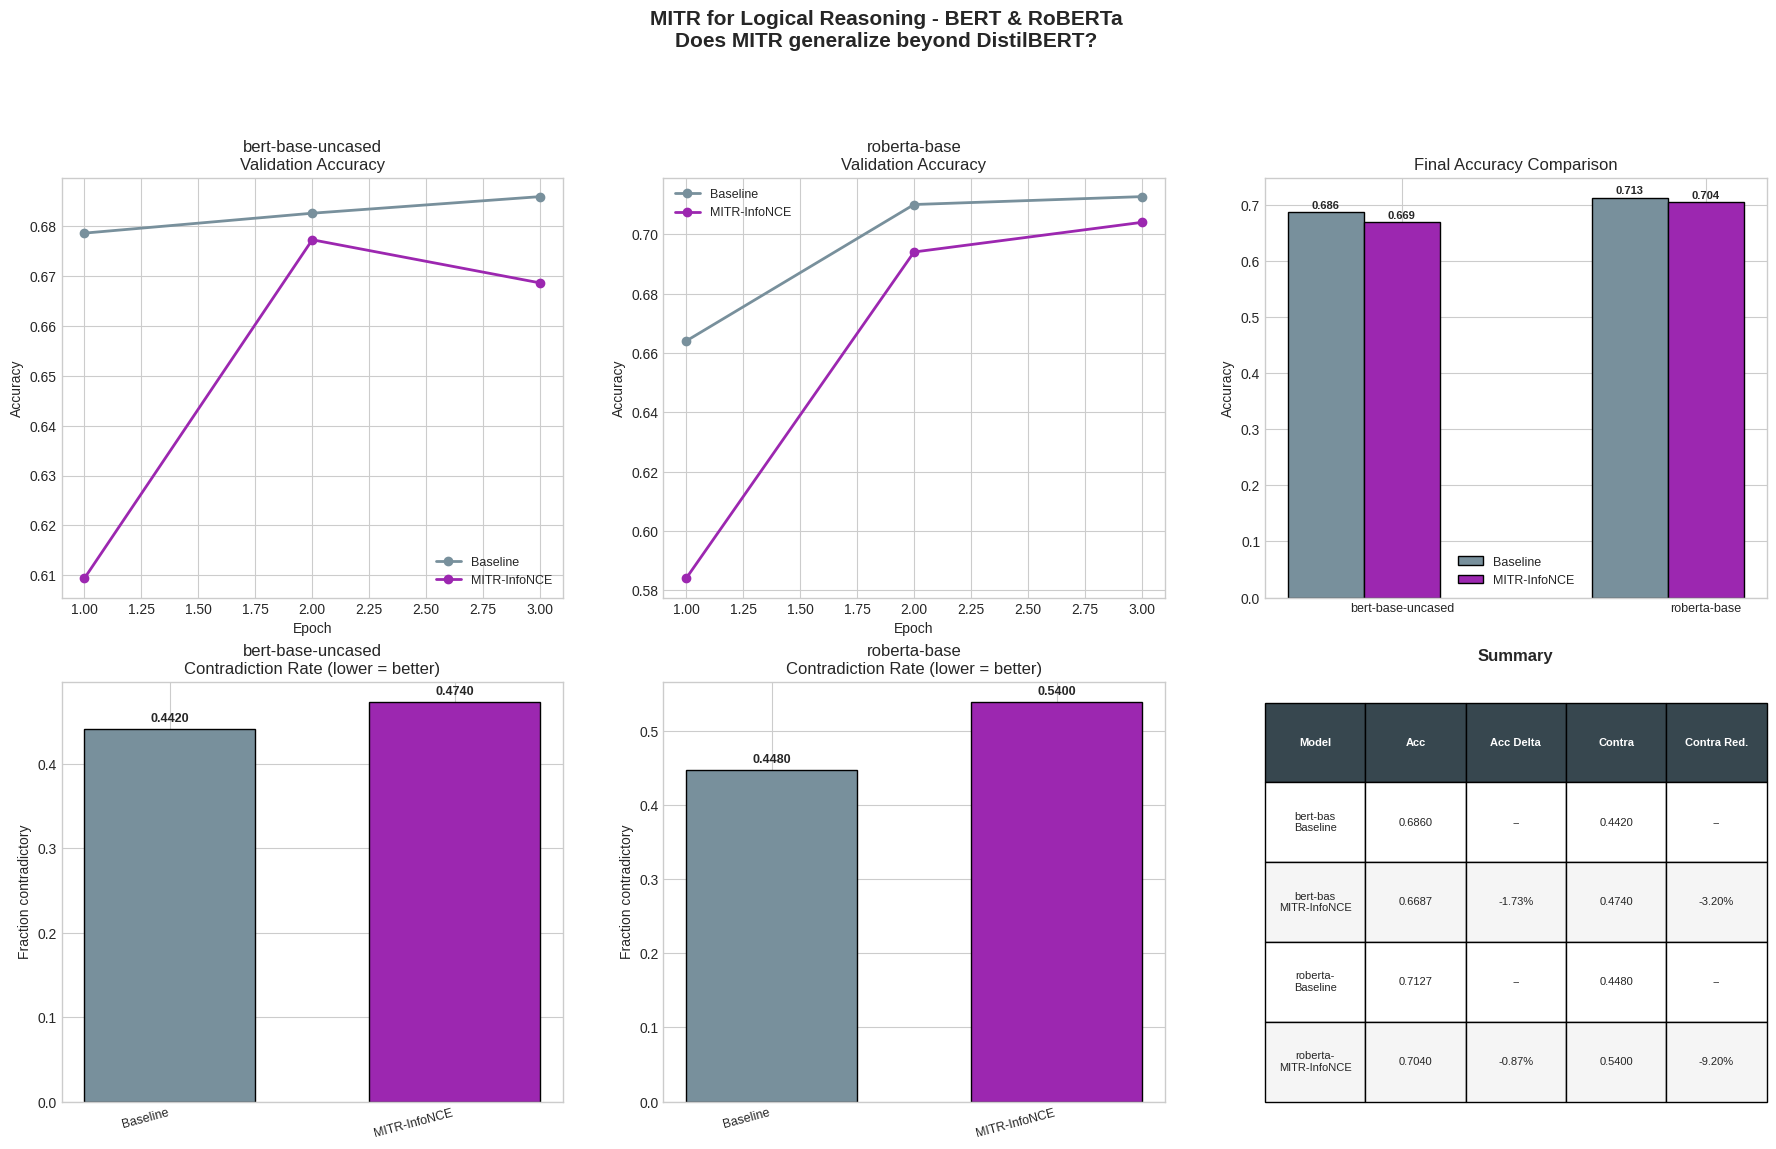

Figure saved -> experiment_results/mitr_bert_roberta_results.png


In [14]:
# -- Visualization: compare all 3 backbones (including DistilBERT from prior run) --

def plot_cross_model_results(results, output_dir="experiment_results"):
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        plt.style.use("seaborn-whitegrid")

    backbones = ["bert-base-uncased", "roberta-base"]
    configs   = ["baseline", "InfoNCE"]
    labels    = ["Baseline","MITR-InfoNCE"]

    COLORS = {"baseline": "#78909C", "InfoNCE": "#9C27B0"}

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))

    for col, backbone in enumerate(backbones):
        short = backbone.split("/")[-1]

        # Top row: training curves
        ax = axes[0, col]
        for cfg_name, label in zip(configs, labels):
            key = f"{short}_{cfg_name}"
            if key not in results:
                continue
            r = results[key]
            ax.plot(r["history"]["epoch"], r["history"]["val_accuracy"],
                    color=COLORS[cfg_name], marker="o", label=label, linewidth=2)
        ax.set(title=f"{short}\nValidation Accuracy", xlabel="Epoch", ylabel="Accuracy")
        ax.legend(fontsize=9)

    # Top-right: cross-model accuracy comparison
    ax = axes[0, 2]
    x = np.arange(len(backbones))
    width = 0.25
    for i, (cfg_name, label) in enumerate(zip(configs, labels)):
        vals = []
        for backbone in backbones:
            short = backbone.split("/")[-1]
            key = f"{short}_{cfg_name}"
            vals.append(results[key]["final_accuracy"] if key in results else 0)
        bars = ax.bar(x + i * width, vals, width, label=label, color=COLORS[cfg_name],
                      edgecolor="black")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(x + width)
    ax.set_xticklabels([b.split("/")[-1] for b in backbones], fontsize=9)
    ax.set(title="Final Accuracy Comparison", ylabel="Accuracy")
    ax.legend(fontsize=9)

    # Bottom-left & center: contradiction rate per backbone
    for col, backbone in enumerate(backbones):
        short = backbone.split("/")[-1]
        ax = axes[1, col]
        names_plot = []
        rates_plot = []
        colors_plot = []
        for cfg_name, label in zip(configs, labels):
            key = f"{short}_{cfg_name}"
            if key not in results:
                continue
            names_plot.append(label)
            rates_plot.append(results[key]["contradiction_rate"])
            colors_plot.append(COLORS[cfg_name])
        bars = ax.bar(range(len(names_plot)), rates_plot, color=colors_plot,
                      width=0.6, edgecolor="black")
        ax.set_xticks(range(len(names_plot)))
        ax.set_xticklabels(names_plot, rotation=15, ha="right", fontsize=9)
        ax.set(title=f"{short}\nContradiction Rate (lower = better)",
               ylabel="Fraction contradictory")
        for bar, r in zip(bars, rates_plot):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{r:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    # Bottom-right: summary table
    ax = axes[1, 2]; ax.axis("off")
    rows = []
    for backbone in backbones:
        short = backbone.split("/")[-1]
        bl_key = f"{short}_baseline"
        if bl_key not in results:
            continue
        bl_acc    = results[bl_key]["final_accuracy"]
        bl_contra = results[bl_key]["contradiction_rate"]
        for cfg_name, label in zip(configs, labels):
            key = f"{short}_{cfg_name}"
            if key not in results:
                continue
            r = results[key]
            acc_d   = (r["final_accuracy"] - bl_acc) * 100
            con_d   = (bl_contra - r["contradiction_rate"]) * 100
            rows.append([
                f"{short[:8]}\n{label}",
                f"{r['final_accuracy']:.4f}",
                f"{acc_d:+.2f}%" if cfg_name != "baseline" else "--",
                f"{r['contradiction_rate']:.4f}",
                f"{con_d:+.2f}%" if cfg_name != "baseline" else "--",
            ])

    tbl = ax.table(
        cellText=rows,
        colLabels=["Model", "Acc", "Acc Delta", "Contra", "Contra Red."],
        cellLoc="center", loc="center", bbox=[0, 0.0, 1, 0.95],
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(8)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#37474F")
            cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#F5F5F5")
    ax.set_title("Summary", fontweight="bold", pad=15)

    fig.suptitle(
        "MITR for Logical Reasoning - BERT & RoBERTa\n"
        "Does MITR generalize beyond DistilBERT?",
        fontsize=15, fontweight="bold", y=1.02,
    )

    out_path = os.path.join(output_dir, "mitr_bert_roberta_results.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved -> {out_path}")


plot_cross_model_results(all_results)

In [15]:
# -- Final summary --

print("\n" + "=" * 70)
print("FINAL RESULTS - BERT & RoBERTa")
print("=" * 70)

print(f"\n{'Model':<30} {'Acc':>8} {'Acc D':>8} {'Contra':>8} {'Contra D':>10}")
print("-" * 68)

for backbone in BACKBONES:
    short  = backbone.split("/")[-1]
    bl_key = f"{short}_baseline"
    if bl_key not in all_results:
        continue

    bl = all_results[bl_key]
    print(f"{short + ' baseline':<30} {bl['final_accuracy']:>8.4f} {'--':>8} "
          f"{bl['contradiction_rate']:>8.4f} {'--':>10}")

    for strategy in MI_STRATEGIES:
        key = f"{short}_{strategy}"
        if key not in all_results:
            continue
        r = all_results[key]
        acc_d = (r["final_accuracy"] - bl["final_accuracy"]) * 100
        con_d = (bl["contradiction_rate"] - r["contradiction_rate"]) * 100
        print(f"{short + ' MITR-' + strategy.upper():<30} {r['final_accuracy']:>8.4f} "
              f"{acc_d:>+7.2f}% {r['contradiction_rate']:>8.4f} {con_d:>+9.2f}%")
    print()

print("\nKey questions answered:")
print("  1. Does MITR work on BERT (the teacher model)?")
print("  2. Does MITR generalize to RoBERTa (different pretraining)?")
print("  3. Does CKA remain the best strategy with 12 layers?")
print(f"\nAll results saved in: experiment_results/")


FINAL RESULTS - BERT & RoBERTa

Model                               Acc    Acc D   Contra   Contra D
--------------------------------------------------------------------
bert-base-uncased baseline       0.6860       --   0.4420         --
bert-base-uncased MITR-INFONCE   0.6687   -1.73%   0.4740     -3.20%

roberta-base baseline            0.7127       --   0.4480         --
roberta-base MITR-INFONCE        0.7040   -0.87%   0.5400     -9.20%


Key questions answered:
  1. Does MITR work on BERT (the teacher model)?
  2. Does MITR generalize to RoBERTa (different pretraining)?
  3. Does CKA remain the best strategy with 12 layers?

All results saved in: experiment_results/
